# ML Homework 4 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW4.ipynb" to "HW4_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together
6. Upload the saved confusion matrix image file together

# [HW 4] Grid search for CNN

1. Load the 'AccData.csv' file as you loaded in the 'ML7_Code2'.
2. Prepare training and test dataset with the test data ratio of """30%""".
3. Perform a grid search to find the best combination of hyperparameters for the CNN model.
  - You can create any combination of hyperparameters.
  - Do not copy 'ML7_Code2' exactly. Set at least one other hyperparamter as the grid search target.
4. Determine your best CNN model based on classification accuracy.
5. Plot a confusion matrix for the best model and save it as an image file (.png or .jpg).
  - Search how to save a figure as an image file.
  - Upload the confusion matrix image to BrightSpace with ipynb and pdf files

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import itertools
import os
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Optional GPU check
device_name = tf.test.gpu_device_name()
print("GPU device:", device_name if device_name else "GPU not found")

GPU device: GPU not found


In [6]:
AccData_pd_load = pd.read_csv('https://github.com/purduelamm/purdue_me597_iiot/blob/main/ml_tutorial/Dataset_Acc/AccData.csv?raw=true').iloc[:,1:]
AccData_pd_load.shape

(360, 2774)

In [7]:
AccData = np.array(AccData_pd_load)
AccData.shape

(360, 2774)

In [8]:
Fs = 12800
f, t, AccSTFT = signal.spectrogram(AccData, Fs, nperseg=78, noverlap=10)
print("AccSTFT shape:", AccSTFT.shape)

AccSTFT shape: (360, 40, 40)


In [9]:
NoOfData = 180

NormalSet   = AccSTFT[:NoOfData]
AbnormalSet = AccSTFT[NoOfData:]

NoOfSensor = 1
NormalSet   = NormalSet.reshape(NormalSet.shape[0], NormalSet.shape[1], NormalSet.shape[2], NoOfSensor)
AbnormalSet = AbnormalSet.reshape(AbnormalSet.shape[0], AbnormalSet.shape[1], AbnormalSet.shape[2], NoOfSensor)

print("NormalSet shape:", NormalSet.shape)
print("AbnormalSet shape:", AbnormalSet.shape)


NormalSet shape: (180, 40, 40, 1)
AbnormalSet shape: (180, 40, 40, 1)


In [10]:
TestData_Ratio = 0.30

TrainData_Nor, TestData_Nor = train_test_split(
    NormalSet, test_size=TestData_Ratio, random_state=777
)
TrainData_Abn, TestData_Abn = train_test_split(
    AbnormalSet, test_size=TestData_Ratio, random_state=777
)

print("Train/Test Normal:", TrainData_Nor.shape, TestData_Nor.shape)
print("Train/Test Abnormal:", TrainData_Abn.shape, TestData_Abn.shape)

Train/Test Normal: (126, 40, 40, 1) (54, 40, 40, 1)
Train/Test Abnormal: (126, 40, 40, 1) (54, 40, 40, 1)


In [11]:
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0], 2))
TrainLabel_Abn = np.zeros((TrainData_Abn.shape[0], 2))
TestLabel_Nor  = np.zeros((TestData_Nor.shape[0], 2))
TestLabel_Abn  = np.zeros((TestData_Abn.shape[0], 2))

# Normal = [1, 0], Abnormal = [0, 1]
TrainLabel_Nor[:, 0] = 1
TrainLabel_Abn[:, 1] = 1
TestLabel_Nor[:, 0]  = 1
TestLabel_Abn[:, 1]  = 1

print(TrainLabel_Nor.shape, TestLabel_Nor.shape)
print(TrainLabel_Abn.shape, TestLabel_Abn.shape)

(126, 2) (54, 2)
(126, 2) (54, 2)


In [12]:
TrainData  = np.concatenate([TrainData_Nor, TrainData_Abn], axis=0)
TestData   = np.concatenate([TestData_Nor, TestData_Abn], axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)
TestLabel  = np.concatenate([TestLabel_Nor, TestLabel_Abn], axis=0)

print("TrainData shape:", TrainData.shape)
print("TestData shape :", TestData.shape)
print("TrainLabel shape:", TrainLabel.shape)
print("TestLabel shape :", TestLabel.shape)

TrainData shape: (252, 40, 40, 1)
TestData shape : (108, 40, 40, 1)
TrainLabel shape: (252, 2)
TestLabel shape : (108, 2)


In [13]:
# Hyperparameters for grid search
param_FiltS   = [3, 5]      # filter(kernel) size
param_FiltN   = [8, 16]     # number of filters
param_Strid   = [1, 2]      # stride
param_Dropout = [0.1, 0.2]  # dropout rate

# Fixed hyperparameters
noOfNeuron   = 16
learningRate = 0.0001
Epoch        = 800

# Calculate the number of cases
NoOfCases = (
    len(param_FiltS) *
    len(param_FiltN) *
    len(param_Strid) *
    len(param_Dropout)
)

print("Total grid search cases:", NoOfCases)

Total grid search cases: 16


In [14]:
def CNN_model(input_data, learningRate, filterSize, numOfFilters, stride, dropoutRate):
    keras.backend.clear_session()

    model = keras.Sequential()
    model.add(keras.layers.InputLayer(shape=(input_data.shape[1], input_data.shape[2], input_data.shape[3])))

    model.add(keras.layers.Conv2D(filters=numOfFilters, kernel_size=(filterSize,filterSize), strides=(stride,stride), padding='same', activation='relu'))
    model.add(keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))

    model.add(keras.layers.Conv2D(filters=numOfFilters*2, kernel_size=(filterSize,filterSize), strides=(1,1), padding='same', activation='relu'))
    model.add(keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(units=noOfNeuron, activation='relu'))   # fixed neuron
    model.add(keras.layers.Dropout(rate=dropoutRate))

    model.add(keras.layers.Dense(units=2, activation='softmax'))

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learningRate),
                  loss=keras.losses.CategoricalCrossentropy(),
                  metrics=['accuracy'])
    return model

In [15]:
Accuracy_df = pd.DataFrame(
    np.zeros(shape=(NoOfCases, 5)),
    columns=['filter size', 'number of filters', 'stride', 'dropout', 'Accuracy']
)

Accuracy_df

,filter size,number of filters,stride,dropout,Accuracy
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0


In [16]:
# Grid search
cnt = 0

for temp_FiltS in param_FiltS:
    for temp_FiltN in param_FiltN:
        for temp_Strid in param_Strid:
            for temp_Dropout in param_Dropout:

                temp_cnn_model = CNN_model(
                    TrainData,
                    learningRate,
                    temp_FiltS,
                    temp_FiltN,
                    temp_Strid,
                    temp_Dropout
                )

                temp_cnn_model.fit(TrainData, TrainLabel, epochs=Epoch, verbose=0)
                Loss, Accuracy = temp_cnn_model.evaluate(TestData, TestLabel, verbose=0)

                temp_cnn_model_name = f'CNN_FS{temp_FiltS}_FN{temp_FiltN}_St{temp_Strid}_Dr{temp_Dropout}.h5'
                temp_cnn_model.save('/content/drive/MyDrive/Colab Notebooks/SavedFiles/ML_Models/GridSearch_CNN_HW4/' + temp_cnn_model_name)

                Accuracy_df.iloc[cnt, :] = [temp_FiltS, temp_FiltN, temp_Strid, temp_Dropout, Accuracy]
                cnt += 1

Accuracy_df

,filter size,number of filters,stride,dropout,Accuracy
0,3.0,8.0,1.0,0.1,0.962963
1,3.0,8.0,1.0,0.2,0.962963
2,3.0,8.0,2.0,0.1,0.962963
3,3.0,8.0,2.0,0.2,0.972222
4,3.0,16.0,1.0,0.1,0.972222
5,3.0,16.0,1.0,0.2,0.972222
6,3.0,16.0,2.0,0.1,0.972222
7,3.0,16.0,2.0,0.2,0.962963
8,5.0,8.0,1.0,0.1,0.962963
9,5.0,8.0,1.0,0.2,0.972222


In [17]:
Accuracy_df_sorted = Accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
Accuracy_df_sorted

# Best case
Best_FiltS   = int(Accuracy_df_sorted.iloc[0, 0])
Best_FiltN   = int(Accuracy_df_sorted.iloc[0, 1])
Best_Strid   = int(Accuracy_df_sorted.iloc[0, 2])
Best_Dropout = float(Accuracy_df_sorted.iloc[0, 3])

print(f"[Best case]\n" +
      f"Filter size   : [{Best_FiltS},{Best_FiltS}]\n" +
      f"Num of Filters: {Best_FiltN}\n" +
      f"Strides       : {Best_Strid}\n" +
      f"Dropout       : {Best_Dropout}\n" +
      "Accuracy      : %.4f" % (Accuracy_df_sorted.iloc[0, 4]))

[Best case]
Filter size   : [3,3]
Num of Filters: 8
Strides       : 2
Dropout       : 0.2
Accuracy      : 0.9722


In [18]:
best_cnn_model_name = f'CNN_FS{Best_FiltS}_FN{Best_FiltN}_St{Best_Strid}_Dr{Best_Dropout}.h5'

best_cnn_model = keras.models.load_model(
    '/content/drive/MyDrive/Colab Notebooks/SavedFiles/ML_Models/GridSearch_CNN_HW4/' + best_cnn_model_name
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


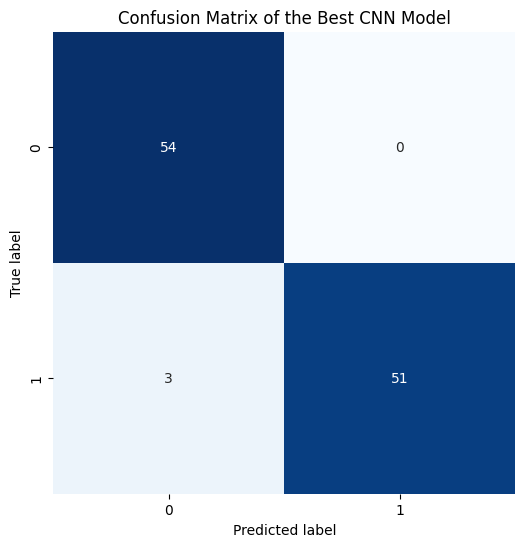

In [22]:
Predicted = best_cnn_model.predict(TestData)

# Convert labels
TestLabel_rev = np.argmax(TestLabel, axis=1)
Predicted_rev = np.argmax(Predicted, axis=1)

# Confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(TestLabel_rev, Predicted_rev)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix of the Best CNN Model")
plt.savefig('/content/drive/MyDrive/best_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
accuracy  = accuracy_score(TestLabel_rev, Predicted_rev)
precision = precision_score(TestLabel_rev, Predicted_rev)
recall    = recall_score(TestLabel_rev, Predicted_rev)
f1_score  = f1_score(TestLabel_rev, Predicted_rev)

print(f"Best CNN Model Evaluation:\n")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1_score:.4f}")

Best CNN Model Evaluation:

Accuracy : 0.9722
Precision: 1.0000
Recall   : 0.9444
F1 Score : 0.9714


## ML7 and ML8 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML7 and ML8.

---

ML7 focuses on classification using sensor data. ML7_Code1 uses feature selection and a basic ANN model, while ML7_Code2 converts raw signals into spectrograms and applies a CNN with hyperparameter tuning using grid search.

---
In contrast, ML8 focuses on image classification using transfer learning, where a pretrained model is adapted to a new dataset (e.g., cats vs dogs).

---
Overall, ML7 builds models from scratch for sensor data, whereas ML8 leverages pretrained models for efficient image-based tasks.


---

### Q2. What skills did you have to develop to accomplish this project?

---

* Data preprocessing and signal processing
* Building and training CNN/ANN models
* Hyperparameter tuning (grid search)
* Model evaluation (accuracy, confusion matrix)
* Using TensorFlow/Keras for deep learning

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

* Understanding how to process raw sensor data into usable inputs (spectrograms)
* Hands-on experience building and training CNN/ANN models
* Learning hyperparameter tuning and its impact on performance
* Interpreting results using accuracy and confusion matrix
* Gaining practical experience with TensorFlow/Keras


---

### Q4. What challenges did you encounter in completing the project?

---

* Achieving high model accuracy and avoiding overfitting
* Selecting appropriate hyperparameters for the CNN (filters, stride, dropout)
* Understanding and preprocessing raw sensor data correctly
* Managing training time during grid search
* Interpreting model performance (precision vs recall trade-offs)


---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

* Tuned hyperparameters (filters, stride, dropout, epochs) using grid search
* Improved model architecture (adjusted layers and neurons)
* Preprocessed data carefully (spectrogram conversion and normalization)
* Monitored performance using validation and confusion matrix
* Increased training epochs and refined model based on results


---